In [1]:
import math
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdDepictor, AllChem, rdMolDescriptors, Descriptors, Crippen
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator, AdditionalOutput
from mordred import Calculator, descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from IPython.display import SVG, display


import py3Dmol
from rdkit.Chem.Descriptors3D import (
    Asphericity, Eccentricity, InertialShapeFactor, NPR1, NPR2, PBF,
    PMI1, PMI2, PMI3, RadiusOfGyration, SpherocityIndex
)

In [2]:
drugs = {
    "aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",              # acetylsalicylic acid
    "ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",       # ibuprofen (racemic)
    "paracetamol": "CC(=O)NC1=CC=C(C=C1)O"              # acetaminophen (paracetamol)
}

functional_groups = {
    "Hydroxyl": "[OX2H]",              # -OH
    "Carbonyl": "[CX3]=O",             # C=O
    "Carboxylic acid": "[CX3](=O)[OX2H1]", # -COOH
    "Amine (primary)": "[NX3;H2]",     # -NH2
    "Amine (secondary)": "[NX3;H1]",   # -NH-
    "Amide": "[NX3][CX3](=O)",         # -CONH-
    "Ester": "[CX3](=O)[OX2][#6]",     # -COO-R
    "Ether": "[OD2]([#6])[#6]"         # R-O-R
}

# functional_groups = {
#     "-OH": "[OX2H]",                        # Hydroxyl
#     "-COOH": "[CX3](=O)[OX2H1]",            # Carboxylic acid
#     "-NH2": "[NX3;H2]",                     # Primary amine
#     "-NH-": "[NX3;H1]",                     # Secondary amine
#     "-CONH-": "[NX3][CX3](=O)",             # Amide
#     "-COO-": "[CX3](=O)[OX2][#6]",          # Ester
#     "-O-": "[OD2]([#6])[#6]",               # Ether
#     "-C=O": "[CX3]=O",                      # Carbonyl (general)
#     "-CH3": "[CX4H3]"                       # Methyl group
# }

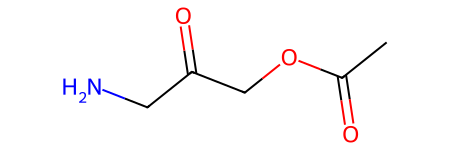

In [3]:
mol = Chem.MolFromSmiles("CC(=O)OCC(=O)CN")
mol

In [4]:
for atom in mol.GetAtoms():
    print(f"Atom: {atom.GetSymbol()}, Index: {atom.GetIdx()}")

Atom: C, Index: 0
Atom: C, Index: 1
Atom: O, Index: 2
Atom: O, Index: 3
Atom: C, Index: 4
Atom: C, Index: 5
Atom: O, Index: 6
Atom: C, Index: 7
Atom: N, Index: 8


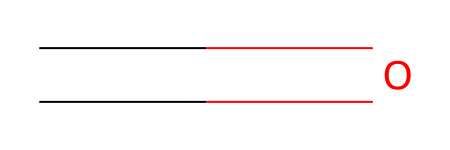

In [9]:
smarts = "[CX3]=O"#"[CX3](=O)[OX2][#6]"
fg_mol = Chem.MolFromSmarts(smarts)
fg_mol


In [13]:
idx = mol.GetSubstructMatches(fg_mol)
idx

((1, 2), (5, 6))

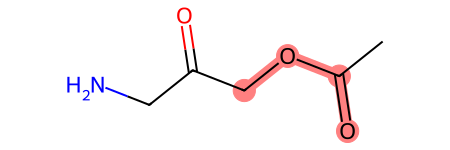

In [7]:
# Chem.Smarts
mol

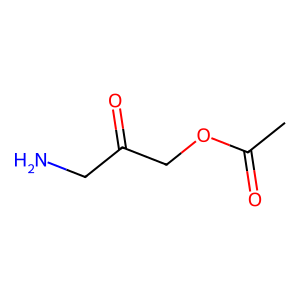

In [8]:
Draw.MolToImage(mol)

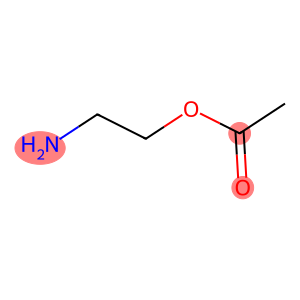

In [4]:
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles("CC(=O)OCCN")
highlight_atoms = []

# highlight all carbonyl and amine atoms
for fg in ["Carbonyl", "Amine (primary)"]:
    smarts = functional_groups[fg]
    fg_mol = Chem.MolFromSmarts(smarts)
    highlight_atoms.extend([idx for match in mol.GetSubstructMatches(fg_mol) for idx in match])

Draw.MolToImage(mol, highlightAtoms=highlight_atoms)


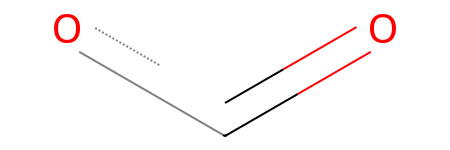

In [5]:
compiled = {name: Chem.MolFromSmarts(pat) for name, pat in functional_groups.items()}
compiled['Carboxylic acid']#, functional_groups['Carboxylic acid']

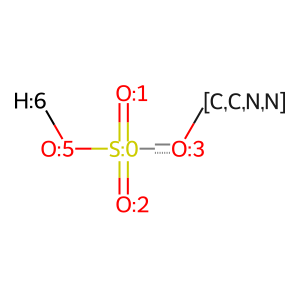

In [6]:
from rdkit import Chem
from rdkit.Chem import Draw

smarts = "[SX4:0](=[O:1])(=[O:2])([O:3]-[C,c,N,n:4])-[OX2:5]-[H:6]"
mol = Chem.MolFromSmarts(smarts)
Draw.MolToImage(mol, size=(300,300))



SMARTS: [CH3]#[C]-[OH]
0 TRIPLE
1 SINGLE

SMARTS: [C][C]~[O]
0 SINGLE
1 UNSPECIFIED

SMARTS: [CH3]=[C](=S)[OH]
0 DOUBLE
1 DOUBLE
2 SINGLE


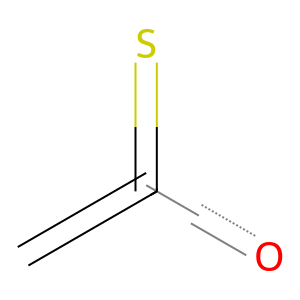

In [43]:
from rdkit import Chem
from rdkit.Chem import Draw

# mol = Chem.MolFromSmarts("[CH3]-[CH2]-[OH]")  # explicit single bonds
# Draw.MolToImage(mol)

def show_bonds(smarts):
    mol = Chem.MolFromSmarts(smarts)
    print(f"\nSMARTS: {smarts}")
    for bond in mol.GetBonds():
        print(bond.GetIdx(), bond.GetBondType())
    return mol

show_bonds("[CH3]#[C]-[OH]")
show_bonds("[C][C]~[O]")
mol = show_bonds("[CH3]=[C](=S)[OH]")


# mol = Chem.MolFromSmarts("[C]#[C]#[O]")
Draw.MolToImage(mol)


In [54]:
from rdkit.Chem import rdMolDescriptors
import rdkit.Chem.Fragments as F

def get_functional_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fgs = rdMolDescriptors.GetUSRScore
    # better: use SMARTS library like "rdkit.Chem.Fragments"
    import rdkit.Chem.Fragments as F
    result = {}
    for name in dir(F):
        if name.startswith("fr_"):
            func = getattr(F, name)
            result[name] = func(mol)
    return {k:v for k,v in result.items() if v>0}

print(get_functional_groups("CCO"))
print(get_functional_groups("CC=O"))


{'fr_Al_OH': 1, 'fr_Al_OH_noTert': 1}
{'fr_C_O': 1, 'fr_C_O_noCOO': 1, 'fr_aldehyde': 1}


In [68]:
# dir(F)
from rdkit import Chem
from rdkit.Chem import rdFMCS

# Example molecules
## CCOC(=O)c1ccc(O)cc1	Oc1ccccc1	[*:1]c1ccc(O)cc1	[*:1]C(=O)OCC	8.34	9.99	acid	1.65
# smiles1 = "Cc1cc(O)ccc1Cl"     # molecule 1
# smiles2 = "Oc1ccc(Cl)cc1"      # molecule 2

smiles1 = "CCOC(=O)c1ccc(O)cc1"     # molecule 1
smiles2 = "Oc1ccccc1"      # molecule 2

mol1 = Chem.MolFromSmiles(smiles1)
mol2 = Chem.MolFromSmiles(smiles2)

# Step 1: Find Maximum Common Substructure (MCS)
mcs_result = rdFMCS.FindMCS([mol1, mol2])

# Step 2: Get the SMARTS of the core (MCS)
mcs_smarts = mcs_result.smartsString
print("MCS SMARTS:", Chem.MolToSmiles(Chem.MolFromSmarts(mcs_smarts)))

# Step 3: Convert the MCS SMARTS to a molecule
core_mol = Chem.MolFromSmarts(mcs_smarts)

# Step 4: Find which atoms belong to the MCS in each molecule
match1 = mol1.GetSubstructMatch(core_mol)
match2 = mol2.GetSubstructMatch(core_mol)

# Step 5: Identify atoms not in the MCS → substituents
subs_atoms_1 = [a.GetIdx() for a in mol1.GetAtoms() if a.GetIdx() not in match1]
subs_atoms_2 = [a.GetIdx() for a in mol2.GetAtoms() if a.GetIdx() not in match2]

# Step 6: Extract substituent fragments as new molecules
substituent1 = Chem.PathToSubmol(mol1, subs_atoms_1) if subs_atoms_1 else None
substituent2 = Chem.PathToSubmol(mol2, subs_atoms_2) if subs_atoms_2 else None

print("Substituent 1 (SMILES):", Chem.MolToSmiles(substituent1) if substituent1 else None)
print("Substituent 2 (SMILES):", Chem.MolToSmiles(substituent2) if substituent2 else None)


MCS SMARTS: OC1:C:C:C:C:C:1
Substituent 1 (SMILES): CCOC(c)=O
Substituent 2 (SMILES): None



--- aspirin ---
SMILES: CC(=O)OC1=CC=CC=C1C(=O)O
hydroxyl: 1 match(es).
  Match 1 atom indices: (12,)


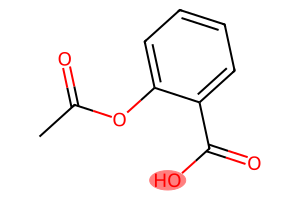

phenol: 0 match(es).
carboxylic_acid: 1 match(es).
  Match 1 atom indices: (10, 11, 12)


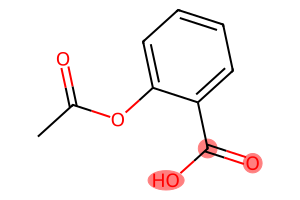

aromatic_ring: 1 match(es).
  Match 1 atom indices: (4, 5, 6, 7, 8, 9)


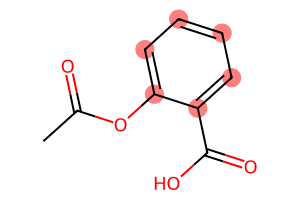

amide: 0 match(es).
ester: 1 match(es).
  Match 1 atom indices: (1, 2, 3, 4)


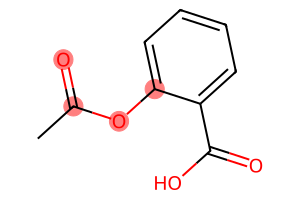

aromatic_nitro: 0 match(es).
primary_amine: 0 match(es).

--- ibuprofen ---
SMILES: CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
hydroxyl: 1 match(es).
  Match 1 atom indices: (14,)


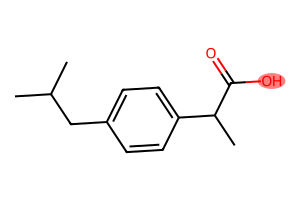

phenol: 0 match(es).
carboxylic_acid: 1 match(es).
  Match 1 atom indices: (12, 13, 14)


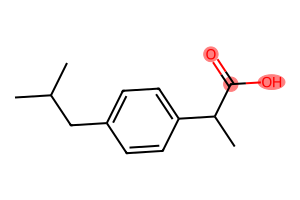

aromatic_ring: 1 match(es).
  Match 1 atom indices: (4, 5, 6, 7, 8, 9)


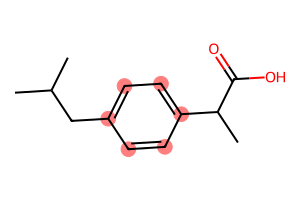

amide: 0 match(es).
ester: 0 match(es).
aromatic_nitro: 0 match(es).
primary_amine: 0 match(es).

--- paracetamol ---
SMILES: CC(=O)NC1=CC=C(C=C1)O
hydroxyl: 1 match(es).
  Match 1 atom indices: (10,)


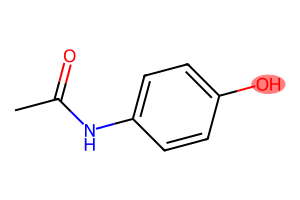

phenol: 1 match(es).
  Match 1 atom indices: (10, 7, 6, 5, 4, 9, 8)


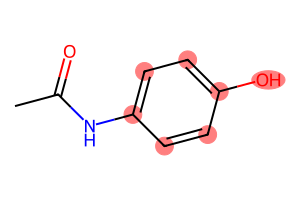

carboxylic_acid: 0 match(es).
aromatic_ring: 1 match(es).
  Match 1 atom indices: (4, 5, 6, 7, 8, 9)


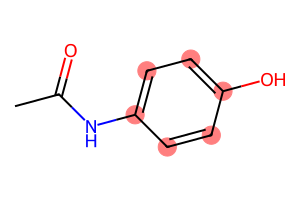

amide: 1 match(es).
  Match 1 atom indices: (3, 1, 2, 0)


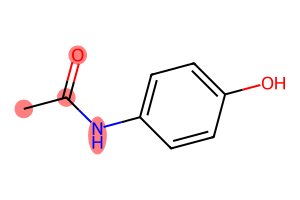

ester: 0 match(es).
aromatic_nitro: 0 match(es).
primary_amine: 0 match(es).

Testing [OH]c1ccccc1 on aspirin: matches = False

Testing [OH]c1ccccc1 on ibuprofen: matches = False

Testing [OH]c1ccccc1 on paracetamol: matches = True


In [51]:
# Save this as smarts_practice.py or run in a Jupyter cell
# Install RDKit first if needed:
# conda install -c conda-forge rdkit
# or: pip install rdkit-pypi


# 1) SMARTS patterns dictionary (useful functional groups)
SMARTS = {
    "hydroxyl": "[OX2H]",                  # -OH (alcohol hydroxyl with one H)
    "phenol": "[OH]c1ccccc1",              # phenolic OH on aromatic ring
    "carboxylic_acid": "[CX3](=O)[OX2H1]", # carboxylic acid R-COOH
    "aromatic_ring": "c1ccccc1",           # benzene-like aromatic ring
    "amide": "[NX3][CX3](=O)[#6]",         # simple amide (N-C(=O)-C)
    "ester": "[CX3](=O)O[#6]",             # ester C(=O)O-C
    "aromatic_nitro": "[NX3](=O)=O",       # nitro (note: simplified)
    "primary_amine": "[NX3;H2]"            # NH2 (primary amine)
}

# 2) A small drug list with SMILES (SMILES from PubChem)
drugs = {
    "aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",              # acetylsalicylic acid
    "ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",       # ibuprofen (racemic)
    "paracetamol": "CC(=O)NC1=CC=C(C=C1)O"              # acetaminophen (paracetamol)
}

# 3) compile SMARTS into RDKit Mol objects
compiled = {name: Chem.MolFromSmarts(pat) for name, pat in SMARTS.items()}

# 4) helper to show molecule with highlighted atom indices
def show_match(smiles, match_atoms, mol_size=(300, 200), mol_name=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES:", smiles)
        return
    # Compute 2D coords for nicer drawing
    # Chem.rdDepictor.Compute2DCoords(mol)
    drawer = rdMolDraw2D.MolDraw2DSVG(mol_size[0], mol_size[1])
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol, highlightAtoms=match_atoms)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText().replace('svg:', '')
    if mol_name:
        display(SVG(svg))
    else:
        display(SVG(svg))

# 5) Run matches and show output
for drug_name, smi in drugs.items():
    mol = Chem.MolFromSmiles(smi)
    print(f"\n--- {drug_name} ---\nSMILES: {smi}")
    for pat_name, pat_mol in compiled.items():
        matches = mol.GetSubstructMatches(pat_mol)
        print(f"{pat_name}: {len(matches)} match(es).")
        if matches:
            for i, match in enumerate(matches):
                print(f"  Match {i+1} atom indices: {match}")
            # show first match visually (highlight atoms)
            show_match(smi, matches[0], mol_name=f"{drug_name} — {pat_name}")

# 6) Example: testing a new SMARTS
# Example: phenolic OH SMARTS used above: [OH]c1ccccc1
test_smarts = "[OH]c1ccccc1"
pat = Chem.MolFromSmarts(test_smarts)
for name, smi in drugs.items():
    mol = Chem.MolFromSmiles(smi)
    print(f"\nTesting {test_smarts} on {name}: matches = {mol.HasSubstructMatch(pat)}")


In [3]:
mol = Chem.MolFromSmiles('c1ccccc1')
Chem.rdDepictor.Compute2DCoords(mol)


0

# Compare overlapping and non-overlapping parts of two compounds

In [26]:
from rdkit import Chem
from rdkit.Chem import rdFMCS

smiles1 = "CC(=O)Oc1ccccc1C(=O)O"   # Aspirin
smiles2 = "CC(=O)Oc1ccccc1NC"        # Phenyl acetate

mol1 = Chem.MolFromSmiles(smiles1)
mol2 = Chem.MolFromSmiles(smiles2)


In [27]:
from rdkit.Chem.Scaffolds import MurckoScaffold

scaf1 = MurckoScaffold.GetScaffoldForMol(mol1)
scaf2 = MurckoScaffold.GetScaffoldForMol(mol2)


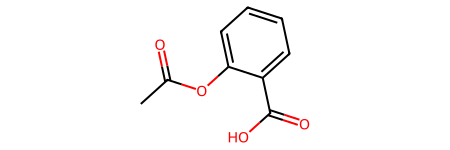

In [28]:
mol1

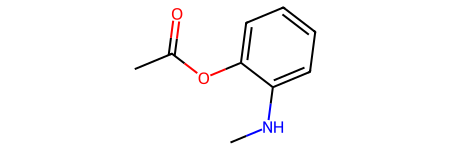

In [29]:
mol2

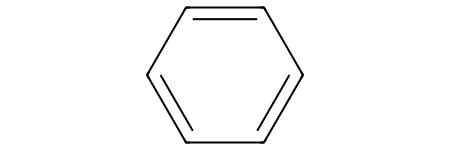

In [31]:
scaf1

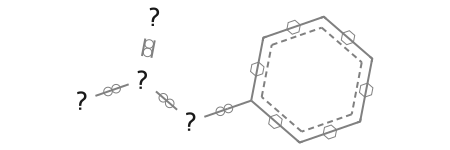

In [20]:
mcs_result = rdFMCS.FindMCS(
    [mol1, mol2],
    ringMatchesRingOnly=True,
    completeRingsOnly=True,
    atomCompare=rdFMCS.AtomCompare.CompareElements,
    bondCompare=rdFMCS.BondCompare.CompareOrder
)

mcs_smarts = mcs_result.smartsString
mcs_mol = Chem.MolFromSmarts(mcs_smarts)
mcs_mol

In [21]:
mcs_smarts

'[#6&!R]-&!@[#6&!R](=&!@[#8&!R])-&!@[#8&!R]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1'

In [22]:
match1 = mol1.GetSubstructMatch(mcs_mol)
match2 = mol2.GetSubstructMatch(mcs_mol)

set1 = set(match1)
set2 = set(match2)

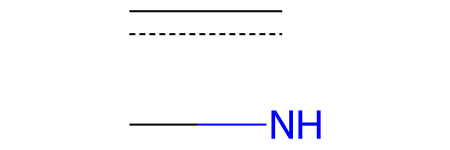

In [23]:
unique_atoms_1 = [a.GetIdx() for a in mol1.GetAtoms() if a.GetIdx() not in set1]
unique_atoms_2 = [a.GetIdx() for a in mol2.GetAtoms() if a.GetIdx() not in set2]

from rdkit.Chem import rdmolops

def extract_submol(mol, atom_indices):
    return rdmolops.PathToSubmol(mol, atom_indices)

common_substructure = mcs_mol
unique_mol1 = extract_submol(mol1, unique_atoms_1)
unique_mol2 = extract_submol(mol2, unique_atoms_2)

unique_mol2

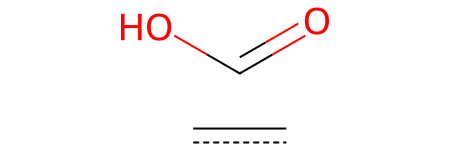

In [25]:
unique_mol1